# Parcel-Facility Join

In [5]:
import geopandas as gpd 
import pandas as pd
import numpy as np

# load parcels
parcels = gpd.read_file("assessor_parcels_analytic.geojson")

# load facilities
facilities_gdf = (
    gpd.read_file("major_fac.geojson")
)

In [6]:
facilities_gdf=facilities_gdf.reset_index().set_index("trifd")
print(facilities_gdf[["name", "air_lbs"]].sort_values("air_lbs"))  # check for zeros before logging

dist = pd.DataFrame(
    {fid: parcels.geometry.distance(geom) / 5280 for fid, geom in facilities_gdf.geometry.items()},
    index=parcels.index,
)  # miles, one column per facility

w_log = np.log10(facilities_gdf["air_lbs"] + 1)
w_log = w_log / w_log.mean()  # mean weight of 1, same scale as unweighted

for lam in [0.5, 1, 2]:
    decay = np.exp(-dist / lam)
    parcels[f"exp_unw_l{lam}"] = decay.sum(axis=1)
    parcels[f"exp_log_l{lam}"] = (decay * w_log).sum(axis=1)  # aligns on trifd

                                                              name    air_lbs
trifd                                                                        
15201MCCNW10948                     MCCONWAY & TORLEY LLC PLT 1801     224.52
1511WTHRML5NRTH  WABTEC COMPONENTS LLC FORMERLY THERMAL TRANSFE...     260.00
15017CYTMPMAYER           UNIVERSAL STAINLESS & ALLOY PRODUCTS INC     488.00
15014LLGHNRIVER              ATI FLAT ROLLED PRODUCTS HOLDINGS LLC    1419.00
15225NVLLC2800N                                NEVILLE CHEMICAL CO   14392.00
15144PPGND125CO               PPG INDUSTRIESINC-SPRINGDALE COMPLEX   22186.09
15104MSDVT13BRA                              TMS INTERNATIONAL LLC   27877.98
15088HRCLSSTATE                      SYNTHOMER JEFFERSON HILLS LLC   50394.00
15034SSRVNPOBOX                 USS MON VALLEY WORKS - IRVIN PLANT   73871.60
15104SSDGRBRADD         USS MON VALLEY WORKS - EDGAR THOMSON PLANT   96883.69
15025SSCLR400ST                                 USS-CLAIRTON PLA

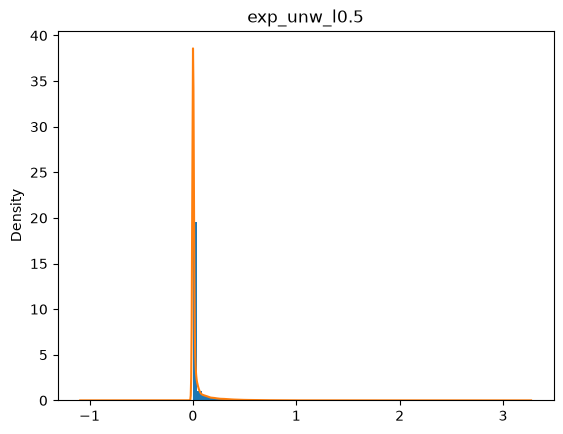

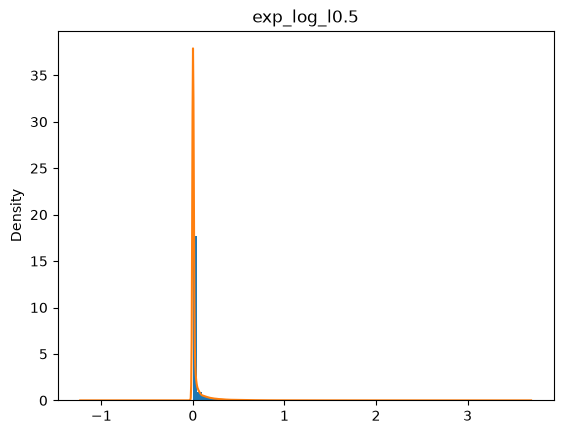

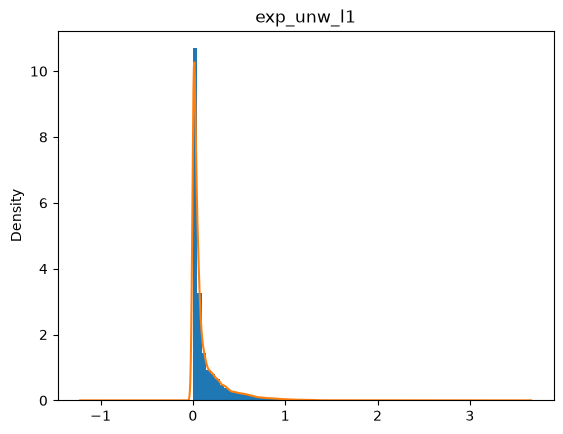

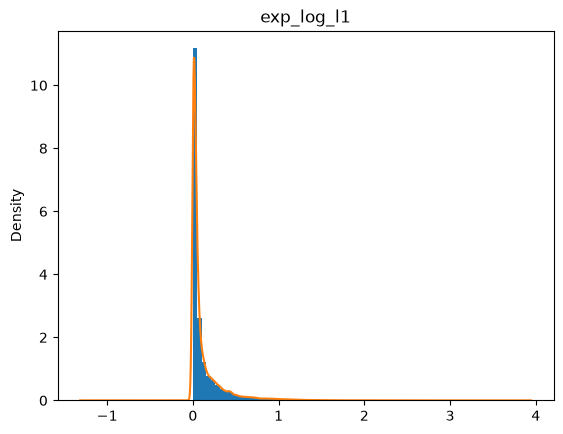

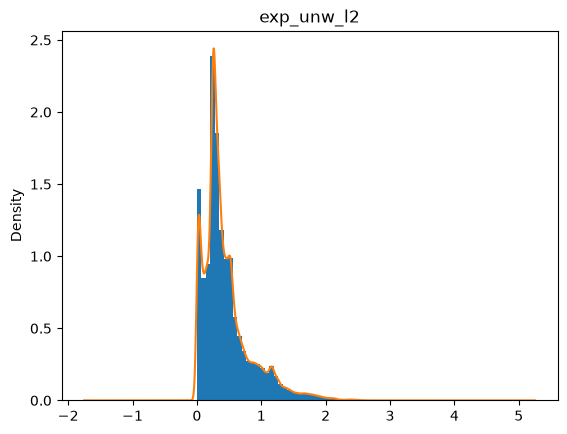

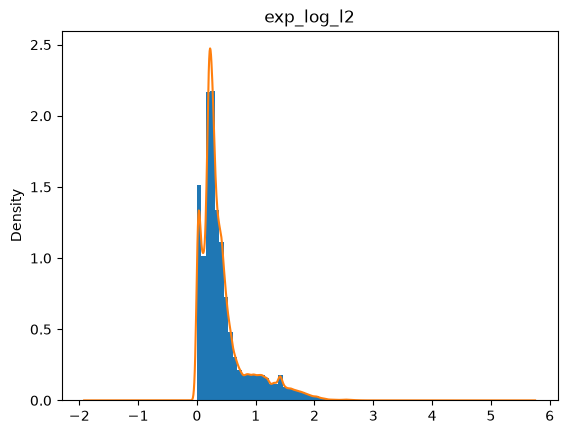

In [7]:
# # inspect results with density plots of each of the decay variables
# import matplotlib.pyplot as plt
# for col in parcels.columns:
#     if col.startswith("exp_"):
#         plt.figure()
#         parcels[col].hist(bins=50, density=True)
#         parcels[col].plot(kind='kde')
#         plt.title(col)
#         plt.show()

In [8]:
parcels.columns

Index(['parid', 'propertycity', 'class', 'classdesc', 'ownerdesc', 'saledate',
       'saleprice', 'countybuilding', 'countyland', 'countytotal',
       'fairmarketbuilding', 'fairmarketland', 'fairmarkettotal', 'taxyear',
       'sale_day', 'sale_month', 'sale_year', '_id', 'map_block_lot',
       'municode', 'calc_acreage', 'comments', 'notes', 'pseudono',
       'shape_length', 'index_right', 'name', 'type', 'region', 'sqmi', 'eoc',
       'lat', 'lon', 'geometry', 'exp_unw_l0.5', 'exp_log_l0.5', 'exp_unw_l1',
       'exp_log_l1', 'exp_unw_l2', 'exp_log_l2'],
      dtype='str')

In [9]:
# download census tract shapefiles

import pygris
from dotenv import load_dotenv
import os
import census as c
from us import states

load_dotenv()
API_KEY = os.getenv("CENSUS_API_KEY")

# alleg = pygris.counties(states.PA.fips).query("NAME == 'Allegheny'").to_crs("EPSG:2272")
allg_tracts = pygris.tracts(states.PA.fips).query("COUNTYFP == '003'").to_crs("EPSG:2272")

Using the default year of 2024


In [16]:
parcels

,parid,propertycity,class,classdesc,ownerdesc,saledate,saleprice,countybuilding,countyland,countytotal,...,eoc,lat,lon,geometry,exp_unw_l0.5,exp_log_l0.5,exp_unw_l1,exp_log_l1,exp_unw_l2,exp_log_l2
0,0001C00228000400,PITTSBURGH,C,COMMERCIAL,CORPORATION,02-25-2016,0.0,2144100,0,2144100,...,City of Pittsburgh,40.44071785017392,-80.0039622513465,"POLYGON ((1341222.492 411419.99, 1341187.212 4...",1.036374e-03,6.108692e-04,0.035346,0.022048,0.309772,0.235513
1,0001D00115000000,PITTSBURGH,C,COMMERCIAL,REGULAR-ETUX OR ET VIR,12-10-1979,255000.0,177500,155900,333400,...,City of Pittsburgh,40.44122133632512,-80.00349009076321,"POLYGON ((1341354.109 411556.955, 1341325.558 ...",1.131909e-03,6.670776e-04,0.036788,0.022903,0.313584,0.237857
2,0001D00117000000,PITTSBURGH,C,COMMERCIAL,CORPORATION,01-17-2014,1400000.0,16330,588470,604800,...,City of Pittsburgh,40.44131121985464,-80.00337112114728,"POLYGON ((1341354.109 411556.955, 1341415.593 ...",1.167568e-03,6.880467e-04,0.037309,0.023207,0.314928,0.238634
3,0001D00125000000,PITTSBURGH,C,COMMERCIAL,CORPORATION,06-21-2002,1.0,466700,422400,889100,...,City of Pittsburgh,40.441407813034715,-80.00287565360333,"POLYGON ((1341529.65 411592.774, 1341575.899 4...",1.218277e-03,7.178511e-04,0.038032,0.023635,0.317113,0.240148
4,0001D00127000000,PITTSBURGH,C,COMMERCIAL,CORPORATION,06-12-2024,1.0,411700,383200,794900,...,City of Pittsburgh,40.441257530287665,-80.00299944711755,"POLYGON ((1341510.025 411557.149, 1341529.65 4...",1.176223e-03,6.931121e-04,0.037426,0.023277,0.315532,0.239211
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
585000,1826D00003000000,WEXFORD,R,RESIDENTIAL,REGULAR-ETUX OR ET VIR,06-04-2026,525000.0,159500,62700,222200,...,NEWCOM,40.64492411389806,-80.037249961512,"POLYGON ((1333997.239 486070.088, 1333976.281 ...",9.063288e-10,9.297823e-10,0.000035,0.000034,0.008779,0.008022
585001,1658R00003000000,WEXFORD,C,COMMERCIAL,CORPORATION,04-05-1999,200000.0,348500,202700,551200,...,NEWCOM,40.62982885495076,-80.05745475010467,"POLYGON ((1328208.89 480711.421, 1328203.198 4...",1.123383e-08,1.163971e-08,0.000115,0.000115,0.014180,0.013325
585002,1825R00006000000,WEXFORD,R,RESIDENTIAL,REGULAR,01-10-2023,0.0,341700,77700,419400,...,NEWCOM,40.63892384803325,-80.05461676834913,"POLYGON ((1329075.183 483985, 1328976.214 4840...",3.118055e-09,3.227741e-09,0.000061,0.000061,0.010591,0.009904
585003,1825A00027000000,WEXFORD,R,RESIDENTIAL,REGULAR,04-28-2004,1.0,51600,80400,132000,...,NEWCOM,40.64663228031732,-80.064481028494,"POLYGON ((1326381.232 486935.865, 1326271.283 ...",1.364153e-09,1.414576e-09,0.000040,0.000040,0.008299,0.007841


In [ ]:
# convert parcels to centroid by dropping geometry column and creating new geom column from lat lon 
parcels_centroid = parcels.drop(columns="geometry")
parcels_centroid["geom"] = gpd.points_from_xy(parcels_centroid["lon"], parcels_centroid["lat"])
parcels_centroid = gpd.GeoDataFrame(parcels_centroid, geometry="geom", crs="EPSG:2272")

parcels_centroid = parcels_centroid.drop(columns=["index_right"], errors="ignore")
allg_tracts = allg_tracts.drop(columns=["index_right"], errors="ignore")

# join parcels with census tracts 
parcels_with_tracts = gpd.sjoin(
    parcels_centroid, 
    allg_tracts, 
    how="left", predicate="intersects")

# take just parcel id and tract id
parcels_with_tracts = parcels_with_tracts[["parid", "GEOID"]]

# rejoin tract info to original parcels file 
parcels = parcels.merge(parcels_with_tracts, on="parid", how="left")

# save new parcels 
parcels.to_file("parcels_with_tracts.geojson", driver="GeoJSON")